In [2]:
import numpy as np
import torch
from typing import Dict, Any
import matplotlib.pyplot as plt
from model_ranking import (
    get_classification_dataloader,
    get_classification_TTA_loaders,
    ResNet,
    load_checkpoint_resnet,
    ClassificationModelConfig,
    ClassificationLoaderConfig
)

INFO: P [MainThread] 2025-09-02 13:49:08,494 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
model_config: Dict[str, Any] = {
    "conv1": {
        "in_channels": 1,
        "out_channels": 64,
        "kernel_size": 7,
        "stride": 2,
        "padding": 3,
        "bias": False,
    },
    "out_channels":1,
    "modelname": "RN18_epfl80_aug5",
    "modelType": "ResNet18",
    "ckpt_path": "/g/kreshuk/talks/FineTuning/experiments/patch_classification/epfl/checkpoints/",
    "ckpt_key": "model_state",
    "feature_layers": [7,8]
}

model_cfg = ClassificationModelConfig.model_validate(model_config)

In [3]:
# Initialize model ONCE
model = ResNet(model_cfg)
device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")
model = load_checkpoint_resnet(
    model_cfg.modelname,
    model=model,
    path=str(model_cfg.ckpt_path),
    location="cpu",
    model_key="ResNet"
)
model = model.to(device)
_ = model.eval()  # Explicitly set to eval mode

/g/kreshuk/talks/model_ranking/src/model_ranking/classification/utils.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_locat

In [45]:
dataloader_config: Dict[str, Any] = {
    "patch_position": {
        "patch_pos_path": '/g/kreshuk/talks/data/epfl/classification_patches/epfl_resized_01_80x80.h5',
        "patch_pos_key": 'validation',
        "roi": None,
        "rnd_seed": None,
        "n_unique_patches": None
    },
    "aug_config": {
        "aug_rnd_seed": None,
        "transform_params": None,
        "raw_transform_params": None,
        "ndim": 2,
        "n_samples": None
    },
    "dataset": {
        "raw_path": "/scratch/talks/data/EPFL/val.h5",
        "raw_key": "raw",
        "mask_path": "/scratch/talks/data/EPFL/val.h5",
        "mask_key": "labels",
        "patch_shape": (1, 80, 80),
        "repeat_patches": False,
        "sample_patches": True,
        "patch_rnd_seed": 2,
        "mask_return_mode": False,
        "patch_return_mode": False,
    },
    "n_samples": 3,
    "ndim": 2,
    "batch_size": 1,
    "shuffle": False,
    "num_workers": 1
}
dataloader_cfg = ClassificationLoaderConfig.model_validate(dataloader_config)

In [46]:
dataloader = get_classification_dataloader(
    dataloader_cfg
)

number of unique patches loaded: 1271


In [47]:
print(len(dataloader.dataset))

3


In [48]:
dataloader.dataset[0][0].numpy().shape

(1, 80, 80)

In [49]:
np.all(np.equal(dataloader.dataset[0][0].numpy(), dataloader.dataset[2][0].numpy()))

False


=== Loop 1 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


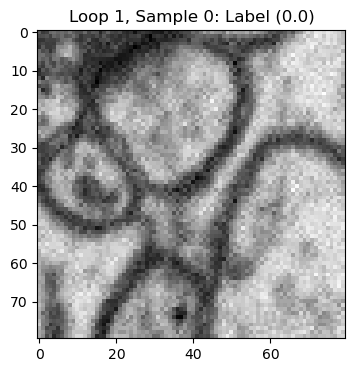

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


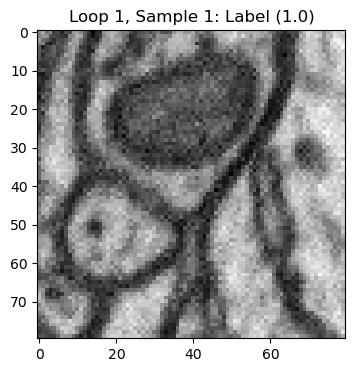

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


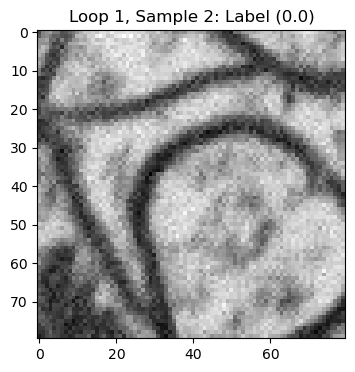


=== Loop 2 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


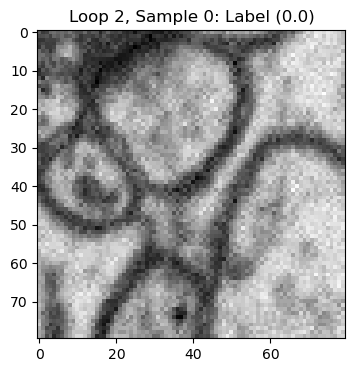

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


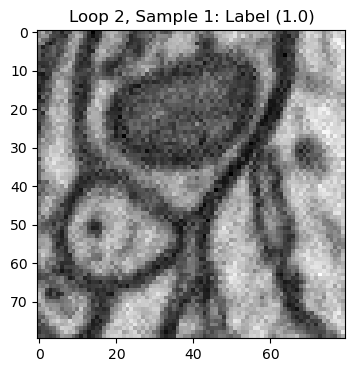

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


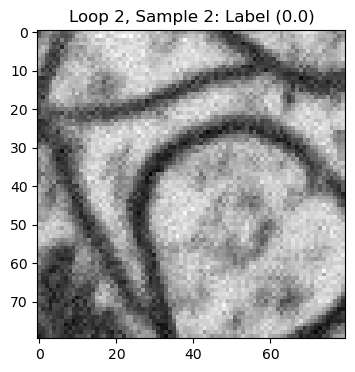


=== Loop 3 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


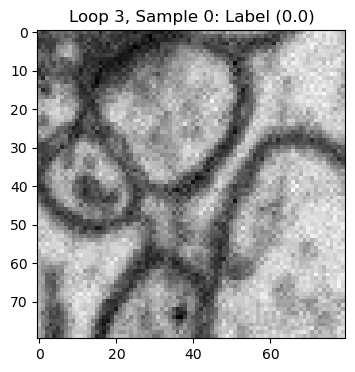

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


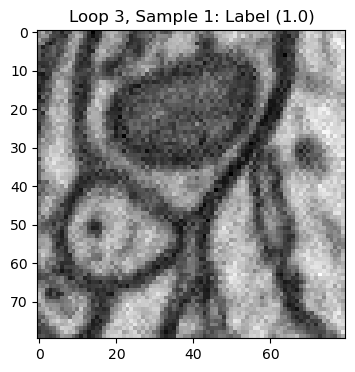

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


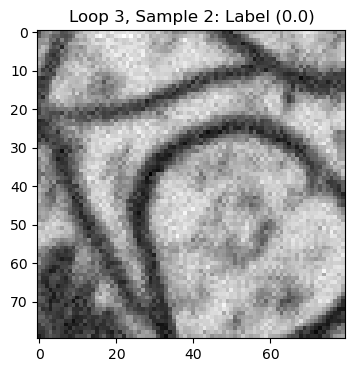

In [50]:
raws = [] 
for loop_num in range(3):
    print(f"\n=== Loop {loop_num + 1} ===")
    for i, (raw, label) in enumerate(dataloader):
        print(f"Sample {i}")
        print(f"Raw shape: {raw.shape}")
        
        plt.figure(figsize=(6, 4))
        _ = plt.imshow(raw.numpy().squeeze(), cmap='grey')
        _ = plt.title(f"Loop {loop_num + 1}, Sample {i}: Label ({label.numpy().squeeze()})")
        plt.show()
        
        raws.append(raw.numpy().copy())
        if i > 3:
            break

In [17]:
np.all(np.equal(raws[0], raws[2]))

True

In [8]:
dataloader.dataset._len

100